In [14]:
import numpy as np
from ibl_info.broja_pid import coinformation
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from scipy.stats import entropy
from sklearn.metrics import mutual_info_score
from matplotlib import pyplot as plt
import seaborn as sns

In [15]:
eids = np.load('../data/processed/eids_with_detailed_insertions.npy', allow_pickle=True)

In [4]:
from brainwidemap import bwm_query, load_trials_and_mask
from ibl_info.prepare_data_pid import compute_intervals
from brainbox.io.one import SpikeSortingLoader, SessionLoader

c:\Users\debot\miniconda3\envs\info-decom\lib\site-packages\ibllib\atlas\__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '


In [5]:
from one.api import ONE

In [52]:
def compute_mi_all(session_id, one):
    return NotImplementedError


In [16]:
def get_variables(trials_df, decoding_interval, second_variable, third_variable=''):


    if decoding_interval=='stim':
        # get left and right visible trials
        # correct_trials =  trials_df[trials_df['feedbackType']==1]

        left_stim_trials = trials_df[trials_df.contrastLeft>0]
        right_stim_trials = trials_df[trials_df.contrastRight>0]
        
        decoding_variable_a = np.concatenate([np.ones((left_stim_trials.shape[0])),-1*np.ones((right_stim_trials.shape[0]))])

        if second_variable=='choice':
            decoding_variable_b = np.concatenate([left_stim_trials.choice, right_stim_trials.choice])
        
        if third_variable=='feedback':
            decoding_variable_c = np.concatenate([left_stim_trials.feedbackType, right_stim_trials.feedbackType])
            return decoding_variable_a, decoding_variable_b, decoding_variable_c
        elif third_variable=='prior':
            decoding_variable_c = np.concatenate([left_stim_trials.prior_binary, right_stim_trials.prior_binary])
            return decoding_variable_a, decoding_variable_b, decoding_variable_c
        else:
            return decoding_variable_a, decoding_variable_b

In [17]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")

In [22]:
def transfromtolog2(x):
    return np.log2(np.exp(x))

In [44]:
def computeMI(x, y):
    sum_mi = 0.0
    x_value_list = np.unique(x)
    y_value_list = np.unique(y)
    Px = np.array([ len(x[x==xval])/float(len(x)) for xval in x_value_list ]) #P(x)
    Py = np.array([ len(y[y==yval])/float(len(y)) for yval in y_value_list ]) #P(y)
    for i in range(len(x_value_list)):
        if Px[i] ==0.:
            continue
        sy = y[x == x_value_list[i]]
        if len(sy)== 0:
            continue
        pxy = np.array([len(sy[sy==yval])/float(len(y))  for yval in y_value_list]) #p(x,y)
        t = pxy[Py>0.]/Py[Py>0.] /Px[i] # log(P(x,y)/( P(x)*P(y))
        sum_mi += sum(pxy[t>0]*np.log2( t[t>0]) ) # sum ( P(x,y)* log(P(x,y)/( P(x)*P(y)) )
    return sum_mi

In [45]:
data_mi = np.zeros((len(eids), 3))


for idx, session_id in enumerate(eids):
    sl = SessionLoader(one, eid=session_id)
    epoch = 'stim'
    if epoch=='stim':
        trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=False)
    else:
        trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)

    trials = trials[mask]


    x,y,z = get_variables(trials, 'stim', 'choice', 'feedback')
    ideal_feedback = np.ones(len(z))
    data_mi[idx, :] = computeMI(x,y), computeMI(y,z), computeMI(x,z)


Text(0.5, 1.0, 'Sanity check')

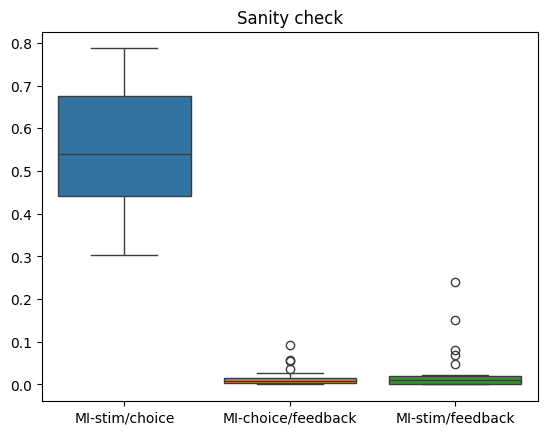

In [48]:
sns.boxplot(data_mi)
plt.xticks(np.arange(3),['MI-stim/choice','MI-choice/feedback','MI-stim/feedback'])
plt.title('Sanity check')

In [122]:
import pandas as pd

In [123]:
def load_action_kernel(eid):
    location = f'D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\raw\\{eid}_actionkernel_prior.csv'
    df = pd.read_csv(location)
    return df['prior']

In [124]:
prior = load_action_kernel(session_id)
trials['prior'] = prior
trials['prior_binary'] = np.asarray(trials['prior']>=0.5, dtype=np.int16)


In [221]:
data = np.zeros((len(eids),4))

for idx, session_id in enumerate(eids):

    sl = SessionLoader(one, eid=session_id)
    epoch = 'stim'
    if epoch=='stim':
        trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=False)
    else:
        trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)

    trials = trials[mask]
    prior = load_action_kernel(session_id)
    trials['prior'] = prior
    trials['prior_binary'] = np.asarray(trials['prior']>=0.5, dtype=np.int16)

    #maybe i am wrong
    # trials['prior_binary'] = trials['prior_binary'].replace({0:1, 1:-1})

    stim,choice,prior = get_variables(trials, decoding_interval='stim', second_variable='choice',third_variable='prior')
    coninfo, trim, miyx1, miyx2 = coinformation(choice,stim,prior)
    data[idx,:] = coninfo, trim, miyx1, miyx2



### check bias for synergy
1. shuffle bias
2. quadratic fit

In [49]:
from scipy.optimize import curve_fit

In [59]:

def equation(N, a, b):
    I_prime = 1
    return I_prime + a / N + b / N**2

def fit(I, N):
    I_prime = 1
    y = I-I_prime 
    X = np.vstack([1/N, 1/N**2]).T
    # popt, pcov = curve_fit(equation, N, I)
    # a, b = popt
    a_b, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
    a,b = a_b
    return a,b

def unbiased_value(I, a, b, N):
    return I-(a/N)-(b/N**2)

In [62]:

from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.behavior.wheel import velocity
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path

from ibl_info.broja_pid import compute_pid, coinformation
from ibl_info.utility import discretize_neural_data
from ibl_info.prepare_data_pid import prepare_ephys_data, compute_intervals
from brainwidemap.bwm_loading import merge_probes
from ibl_info.load_glm_hmm import load_state_dataframe

In [104]:
def generate_source_ids(number_of_neurons):
    combinations_neuronids=[]
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])
    
    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids



def neural_information_content(neural_data, decoding_variable):

    n_neurons = neural_data.shape[0]
    sources = generate_source_ids(n_neurons)
    
    targets = decoding_variable

    pid_information_biased = np.zeros((len(sources), 4)) # neuronsC2 x 4
    pid_information_shuffled = np.zeros((len(sources), 4)) # neuronsC2 x 4
    

    for idx in tqdm(range(len(sources)), desc="Running for all sources",leave=False):
        
        ## biased
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(neural_data[s1, :], dtype=np.int32)
        X2 = np.asarray(neural_data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)
        u1, u2, red, syn = compute_pid(Y, X1, X2)
        pid_information_biased[idx, :] = u1, u2, red, syn

        #shuffle Y
        np.random.shuffle(Y)
        u1, u2, red, syn = compute_pid(Y, X1, X2)
        pid_information_shuffled[idx, :] = u1, u2, red, syn

    return pid_information_biased, pid_information_shuffled

In [63]:
# 'IP' is important
# 'AUD-p'

In [ ]:
session_id_ip = 'aec5d3cc-4bb2-4349-80a9-0395b76f04e2'
session_id_feedback_audp = '6b0b5d24-bcda-4053-a59c-beaa1fe03b8f'

In [237]:
session_id = 'aec5d3cc-4bb2-4349-80a9-0395b76f04e2'
epoch='choice'

sl = SessionLoader(one, eid=session_id)

pids, probes = one.eid2pid(session_id)
if isinstance(probes, list) and len(probes) > 1:
    to_merge = [load_good_units(one, pid=None, eid=session_id, qc=1, pname=probe_name)
                for probe_name in probes]
    spikes, clusters = merge_probes([spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge])
else:   
    spikes, clusters = load_good_units(one, pid=None, eid=session_id, qc=1, pname=probes)

if epoch=='stim':
    trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=False)
else:
    trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)

trials = trials[mask]

intervals, decoding_variable = compute_intervals(trials, epoch)
data_epoch, actual_regions, n_units, cluster_ids = prepare_ephys_data(spikes, clusters, intervals, ['IP']) # to find mice with IP



Region found IP, 114


In [238]:
epoch

'choice'

In [239]:
data_discretized = discretize_neural_data(data_epoch[0].T, 'neuron')

# fig, ax = plt.subplots(ncols=2,figsize=(8,4))
# sns.heatmap(data_discretized, ax=ax[0])
# sns.heatmap(data_epoch[0].T, ax=ax[1])

(114, 439) neuron


100%|██████████| 114/114 [00:00<00:00, 8102.60it/s]


In [240]:
pid_information_biased, pid_information_shuffled = neural_information_content(data_discretized, decoding_variable)

In [242]:
pid_info_unbiased = pid_information_biased - pid_information_shuffled

In [243]:
pid_info_unbiased[pid_info_unbiased<0] = 0

In [244]:
pid_info_unbiased

array([[0.00000000e+00, 4.79861079e-03, 0.00000000e+00, 4.46722470e-03],
       [1.42238388e-10, 2.14379177e-02, 0.00000000e+00, 0.00000000e+00],
       [5.84867793e-10, 1.65750622e-03, 0.00000000e+00, 6.28823584e-03],
       ...,
       [3.36739903e-03, 1.81513881e-10, 6.37930642e-04, 6.56274549e-03],
       [0.00000000e+00, 0.00000000e+00, 2.91627187e-03, 2.74709444e-03],
       [0.00000000e+00, 2.50421278e-03, 0.00000000e+00, 0.00000000e+00]])

In [245]:
means_unbiased = np.mean(pid_info_unbiased, axis=0)
means_biased = np.mean(pid_information_biased, axis=0)

stds_unbiased = np.std(pid_info_unbiased, axis=0)
stds_biased = np.std(pid_information_biased, axis=0)

# rerrange a bit
# new_means_unbiased = [(means_unbiased[0]+means_unbiased[1])/2, means_unbiased[2],means_unbiased[3]]
# new_means_biased = [(means_biased[0]+means_biased[1])/2, means_biased[2],means_biased[3]]

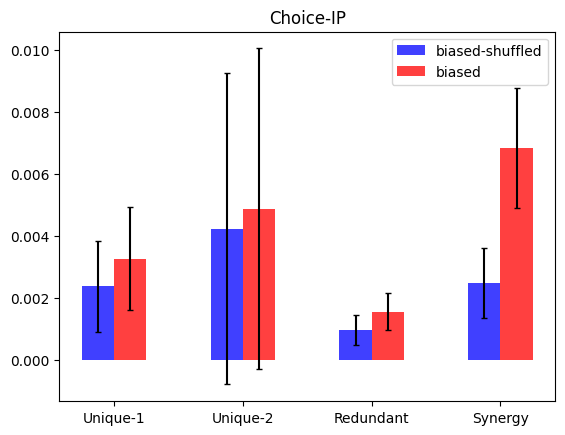

In [247]:
plt.bar(np.arange(4), means_unbiased, width=0.25, color='b', alpha=0.75,label='biased-shuffled', yerr=stds_unbiased/4,capsize=2)
plt.bar(np.arange(4)+0.25, means_biased, width=0.25, color='r', alpha=0.75, label='biased', yerr=stds_biased/4,capsize=2)
plt.xticks(np.arange(4)+0.125,['Unique-1','Unique-2','Redundant','Synergy'])
plt.title('Choice-IP')
plt.legend()